# LOADING LIBRARIES

In [1]:
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split

from src.dataset import load_preprocessed_dataset
from src.plotting import plt_sample, plt_pred

# LOADING DATASET

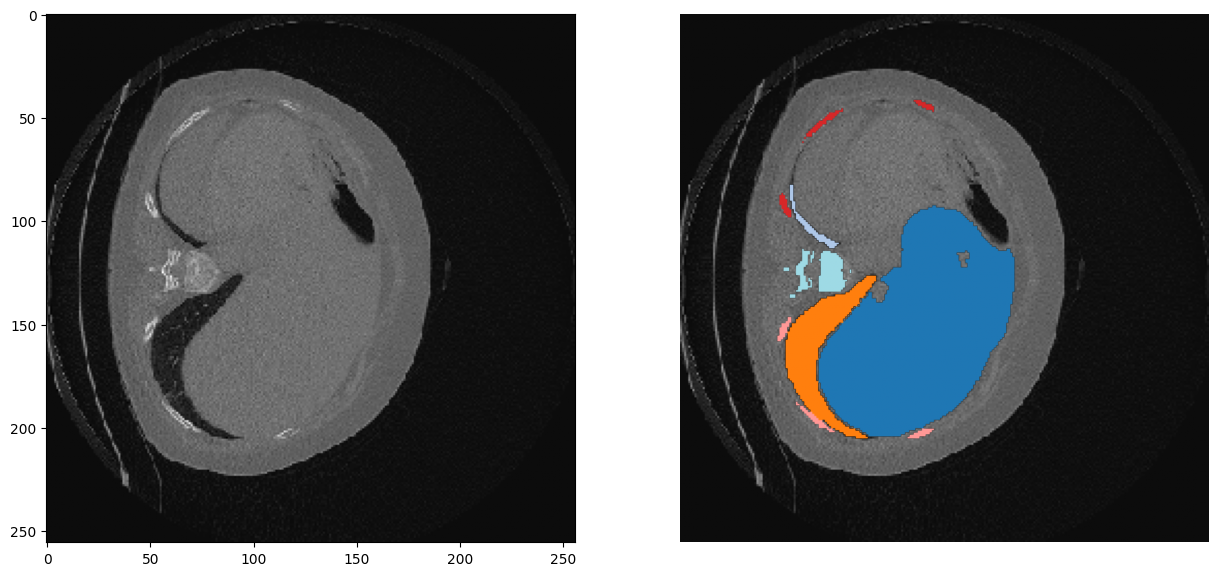

In [2]:
x_train, y_train, x_test = load_preprocessed_dataset()
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=1,
)

SAMPLE_IDX = 0
plt_sample(
    x_train[SAMPLE_IDX].squeeze(),
    y_train[SAMPLE_IDX].squeeze().to(dtype=torch.float32),
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 1
train_ds = TensorDataset(
    x_train.to(device=device, dtype=torch.float32),
    y_train.to(device=device, dtype=torch.long),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

valid_ds = TensorDataset(
    x_valid.to(device=device, dtype=torch.float32),
    y_valid.to(device=device, dtype=torch.long),
)
valid_batch_size = int(np.clip(BATCH_SIZE * 2, a_min=1, a_max=64))
valid_loader = DataLoader(valid_ds, batch_size=valid_batch_size, shuffle=False)

dir_checkpoint = Path('./checkpoints/')

# Swin-UNET

In [4]:
from torch import Tensor
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from src.plotting import plt_pred
from src.metrics import dice_loss, dice_pandas

def train_unet(
        model: nn.Module,
        device: torch.device,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        labels_weights: Tensor,
        n_epochs: int,
        n_classes: int,
        save_checkpoint: bool=True,
        plt_preds: bool=True
    ):

    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    labels_weights = labels_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=labels_weights)
    model = model.to(device)

    for epoch in tqdm(range(n_epochs)):

        model.train()
        train_loss = 0

        for (image, mask) in train_loader:
            image = image.to(device=device)
            mask = mask.to(device=device)
            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                output = model(image)
                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        with torch.no_grad() :
            model.eval()
            test_loss = 0
            predictions = []
            true_masks = []

            for (image, mask) in valid_loader:
                true_masks.append(mask.cpu().numpy().squeeze())
                image = image.to(device=device)
                mask = mask.to(device=device)

                output = model(image)

                pred = torch.argmax(output, dim=1)
                predictions.append(pred.squeeze().cpu().numpy())

                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce

                test_loss += loss.item()

            predictions = pd.DataFrame(np.array(predictions).reshape((-1, 256*256)))
            valid = pd.DataFrame(np.array(true_masks).reshape((-1, 256*256)))
            score = dice_pandas(valid, predictions, n_classes)

        print(f"Epoch : {epoch} \t Training Loss : {train_loss / len(train_loader):.3f} \t Test Loss : {test_loss / len(valid_loader):.3f} \t Score: {score:.3f}")

        if save_checkpoint:
            Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
            state_dict = model.state_dict()
            torch.save(state_dict, str(dir_checkpoint / f'checkpoint_epoch{epoch}.pth'))
        if plt_preds:
            plt_pred(model, 100, x_train, y_train)
            plt_pred(model, 7, x_valid, y_valid)
            plt_pred(model, 20, x_test)


In [5]:
import json
def get_class_weights() -> torch.Tensor:
    file_name = "./dataset/raw/annotated_labels.json"
    with open(file_name, 'r') as file :
        data = json.load(file)

    flattened_data = []
    for i in data :
        flattened_data += i

    labels, labels_count = np.unique(flattened_data, return_counts=True)
    labels_weights = labels_count / np.sum(labels_count)

    # adding the background
    labels_weights = np.insert(labels_weights, 0, 0.0001)
    class_weights = torch.from_numpy(labels_weights).type(torch.float32)
    return class_weights

In [ ]:
from monai.networks.nets import SwinUNETR

NUM_CLASSES = 55
def mk_model() -> nn.Module:
    return SwinUNETR(
        in_channels=1,
        out_channels=NUM_CLASSES,
        feature_size=48,
        spatial_dims=2,
        use_v2=True,
    ).to(device)

model = mk_model()

N_EPOCHS = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = get_class_weights()
train_unet(
    model,
    device,
    train_loader,
    valid_loader,
    class_weights,
    N_EPOCHS,
    NUM_CLASSES,
    save_checkpoint=True,
    plt_preds=False,
)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 	 Training Loss : 1.962 	 Test Loss : 1.691 	 Score: 0.011


In [ ]:
test_model = mk_model()
test_model.load_state_dict(torch.load(str(dir_checkpoint / f'checkpoint_epoch{N_EPOCHS - 1}.pth'), weights_only=True))
test_model = test_model.eval()

In [ ]:
plt_pred(test_model, 100, "train")
plt_pred(test_model, 6, "val")
plt_pred(test_model, 6, "test")

In [ ]:
test_loader = DataLoader(x_test, batch_size=1, shuffle=False)

predictions = []

for image in test_loader :
    image = image.to(device=device)

    output = test_model(image)

    pred = torch.argmax(output, dim=1)
    predictions.append(pred.cpu().numpy())

predictions = np.array(predictions)
print("n unique values:", len(np.unique(predictions)))
df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T

df.index = [f"Pixel {i}" for i in df.index]

df.columns = [f"{col}.png" for col in df.columns]

df.to_csv("submission.csv")